In [25]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly as px

In [26]:
df=pd.read_csv('netflix.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [27]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

### here we deleting unused column and null values

In [28]:
df.dropna(inplace=True)
df.drop(['show_id','director','description','duration','title'],axis=1,inplace=True)
df

,type,cast,country,date_added,release_year,rating,listed_in
7,Movie,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,"Dramas, Independent Movies, International Movies"
8,TV Show,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,"British TV Shows, Reality TV"
9,Movie,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,"Comedies, Dramas"
12,Movie,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,"Dramas, International Movies"
24,Movie,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,"Comedies, International Movies, Romantic Movies"
...,...,...,...,...,...,...,...
8801,Movie,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,"Dramas, International Movies, Thrillers"
8802,Movie,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,"Cult Movies, Dramas, Thrillers"
8804,Movie,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,"Comedies, Horror Movies"
8805,Movie,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,"Children & Family Movies, Comedies"


In [29]:
def handle_date_added(value):
    return int(value[-4:])

df['date_added'] = df['date_added'].apply(handle_date_added)
df

,type,cast,country,date_added,release_year,rating,listed_in
7,Movie,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021,1993,TV-MA,"Dramas, Independent Movies, International Movies"
8,TV Show,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021,2021,TV-14,"British TV Shows, Reality TV"
9,Movie,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021,2021,PG-13,"Comedies, Dramas"
12,Movie,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021,2021,TV-MA,"Dramas, International Movies"
24,Movie,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,2021,1998,TV-14,"Comedies, International Movies, Romantic Movies"
...,...,...,...,...,...,...,...
8801,Movie,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan",2016,2015,TV-MA,"Dramas, International Movies, Thrillers"
8802,Movie,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019,2007,R,"Cult Movies, Dramas, Thrillers"
8804,Movie,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019,2009,R,"Comedies, Horror Movies"
8805,Movie,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020,2006,PG,"Children & Family Movies, Comedies"


In [32]:
df['country'].value_counts()

country
United States                                             1846
India                                                      875
United Kingdom                                             183
Canada                                                     107
Spain                                                       91
                                                          ... 
Germany, Canada, United States                               1
Denmark, United Kingdom, South Africa, Sweden, Belgium       1
Spain, Canada, United States                                 1
United States, United Kingdom, Morocco                       1
Israel, Germany                                              1
Name: count, Length: 604, dtype: int64

In [30]:
df['date_added'].value_counts()

date_added
2019    1265
2020    1194
2018    1101
2021     755
2017     724
2016     202
2015      50
2014      14
2011      13
2013       7
2012       3
2009       2
2008       1
2010       1
Name: count, dtype: int64

In [10]:
df['type'].value_counts()

type
Movie      5185
TV Show     147
Name: count, dtype: int64

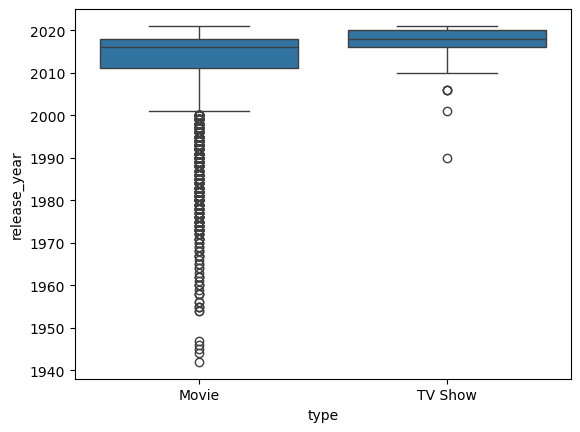

In [15]:
sns.boxplot(x='type',y='release_year',data=df)
plt.show()

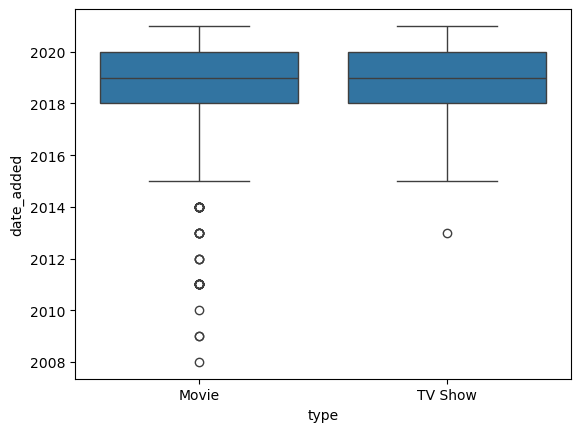

In [10]:
sns.boxplot(x='type',y='date_added',data=df)
plt.show()

In [12]:
df['rating'].value_counts()

rating
TV-MA       1822
TV-14       1214
R            778
PG-13        470
TV-PG        431
PG           275
TV-G          84
TV-Y7         76
TV-Y          76
NR            58
G             40
TV-Y7-FV       3
UR             3
NC-17          2
Name: count, dtype: int64

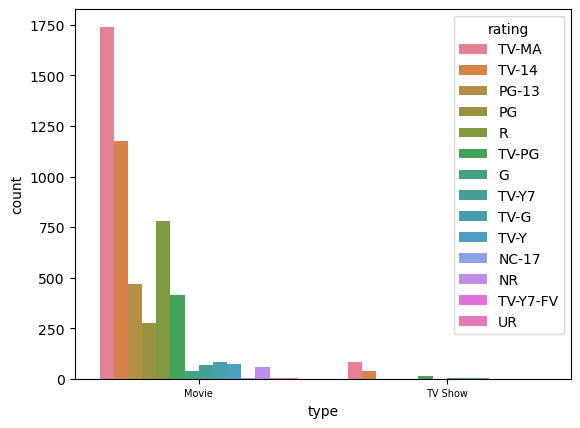

In [13]:
sns.countplot(x='type',data=df, hue='rating')
plt.xticks(fontsize=7)
plt.show()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5332 entries, 7 to 8806
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          5332 non-null   object
 1   cast          5332 non-null   object
 2   country       5332 non-null   object
 3   date_added    5332 non-null   int64 
 4   release_year  5332 non-null   int64 
 5   rating        5332 non-null   object
 6   listed_in     5332 non-null   object
dtypes: int64(2), object(5)
memory usage: 333.2+ KB


In [ ]:
pivot_table=df.pivote_table(